# QCut Subsequent Wires

In [ ]:
import QCut as ck
from QCut import cut
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorEstimator, BackendEstimatorV2 as BackendEstimator
from iqm.qiskit_iqm import IQMFakeApollo

In [ ]:
# Choose the wire cutting communication mode. The options are:
# - "never": No communication between the cut subcircuits.
# - "always": Always communicate between the cut subcircuits.
# - "auto" : Communication on parallel blocks of 2 or more wire cuts.
# Change the value and see how the number of experiments changes.

options = ck.CutOptions(
    wire_cut_communication = "never"
)

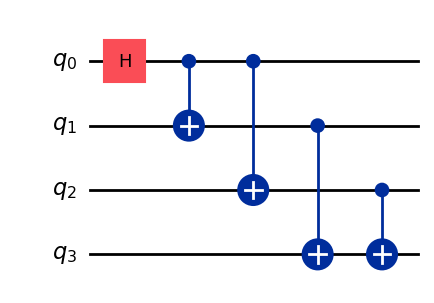

In [75]:
#define initial circuit

circuit = QuantumCircuit(4)
circuit.h(0)
circuit.cx(0,1)
circuit.cx(0,2)
circuit.cx(1,3)
circuit.cx(2,3)

circuit.draw("mpl")

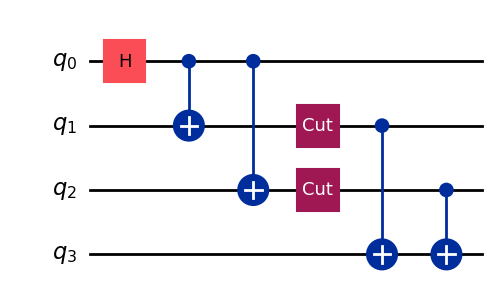

In [76]:
#insert cuts

cut_circuit = QuantumCircuit(4)
cut_circuit.h(0)
cut_circuit.cx(0,1)
cut_circuit.cx(0,2)
cut_circuit.append(cut(), [1])
cut_circuit.append(cut(), [2])
cut_circuit.cx(1,3)
cut_circuit.cx(2,3)

cut_circuit.draw("mpl")

In [77]:
cut_circuit = ck.get_locations_and_subcircuits(cut_circuit)

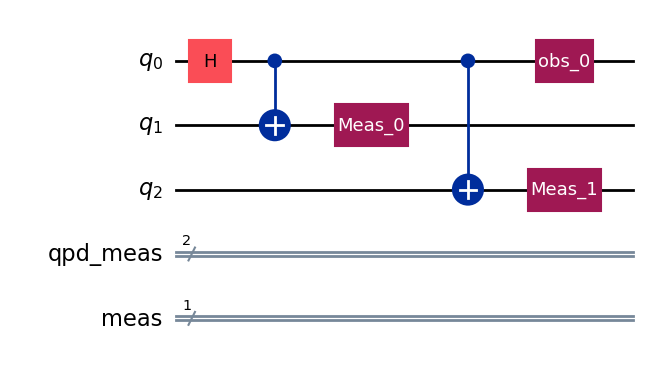

In [78]:
cut_circuit.subcircuits[0].draw("mpl")

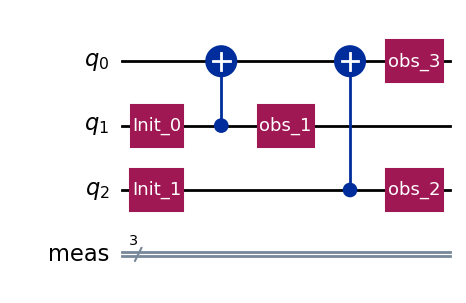

In [79]:
cut_circuit.subcircuits[1].draw("mpl")

In [80]:
#define backends
fake = IQMFakeApollo()
sim = AerSimulator()

In [81]:
transpiled_cut = ck.transpile_subcircuits(cut_circuit, fake, optimization_level=3, use_iqm_transpiler=False)

In [89]:
observables = SparsePauliOp(["IIIZ", "IIZI", "IZII", "IIZZ"])

cut_experiment = ck.get_experiment_circuits(transpiled_cut, observables)

print("Generated {} circuits for the experiment.".format(cut_experiment.num_circuits))

Generated 56 circuits for the experiment.


In [83]:
results = ck.run_experiments(cut_experiment, backend=fake)

In [84]:

#get the approximated expectation values
expectation_values = ck.estimate_expectation_values(results)

In [85]:
obs = [ob.to_label() for ob in observables.paulis]

estimator = StatevectorEstimator()
exact_expvals = [e.data.evs for e in
    estimator.run([(x) for x in zip([circuit] * len(obs), obs)]).result()
]


tr = transpile(circuit, backend=fake)

tr_obs = observables.apply_layout(tr.layout)

tr_obs_separate = [
    SparsePauliOp(pauli.to_label()) for pauli in tr_obs.paulis
]

fake_estimator = BackendEstimator(backend=fake)
exps = [e.data.evs for e in
    fake_estimator.run([(x) for x in zip([tr] * len(tr_obs_separate), tr_obs_separate)]).result()
]

In [86]:
import numpy as np

np.set_printoptions(formatter={"float": lambda x: f"{x:0.6f}"})

print(f"QCut expectation values:{np.array(expectation_values)}")
print(f"Noisy expectation values with fake backend:{np.array(exps)}")
print(f"Exact expectation values with ideal simulator :{np.array(exact_expvals)}")

QCut expectation values:[-0.016843 0.036694 0.007986 0.523365]
Noisy expectation values with fake backend:[0.007324 0.010742 0.003418 0.748047]
Exact expectation values with ideal simulator :[0.000000 0.000000 0.000000 1.000000]
